In [33]:
from re import M

import numpy as np
np.set_printoptions(suppress=True,precision=4)
house=np.genfromtxt('house.txt',delimiter=',')
X=house[:,0]
bedroom=house[:,1]
y=house[:,2]
m=X.shape[0]

X.shape[0],bedroom.shape,y.shape

(47, (47,), (47,))

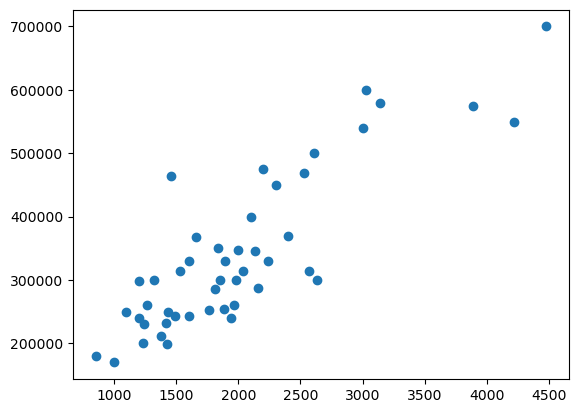

In [11]:
import matplotlib.pyplot as plt

fig,ax=plt.subplots()
ax.scatter(X,y,)

In [140]:
def err(y,y_hat):
    e=y_hat-y
    return np.dot(e,e)/len(y)

def df(X,y,w,b,M):
    dw=0
    db=0
    y_hat_all = np.zeros(M)
    for i in range(M):
        y_hat_all[i]=w*X[i]+b 
        dw+=(X[i]*(y_hat_all[i]-y[i]))
        db+=(y_hat_all[i]-y[i])
        # print(f"df: dw: {dw:8.4f} | db: {db:8.4f}")
    return dw/M,db/M,y_hat_all

def fit(X,y,M,alpha,ite):
    w=0
    b=0
    result=[]
    for _ in range(ite):
        # dw,db,y_hat=df(X,y,w,b,M)
        # w=w-alpha*dw
        # b=b-alpha*db
        # e=err(y,y_hat)
        # # print(f"迭代 {_+1:03d}次 | w: {w:8.4f} | b: {b:8.4f} | Error: {e:10.4f}")
        # result.append((w,b,e))
        # 1. 此时的 y_hat 完全对应当前的 w, b
        dw, db, y_hat = df(X, y, w, b, M)
        
        # 2. 计算当前位置的真实误差 (这就是 Z 坐标)
        e = err(y, y_hat)
        
        # 3. 记录当前的完美 3D 坐标点 (w, b, z)
        result.append((w, b, e))
        
        # 4. 向谷底迈出下一步
        w = w - alpha * dw
        b = b - alpha * db
    return result

In [ ]:
result=fit(X,y,m,0.00000001,1100)

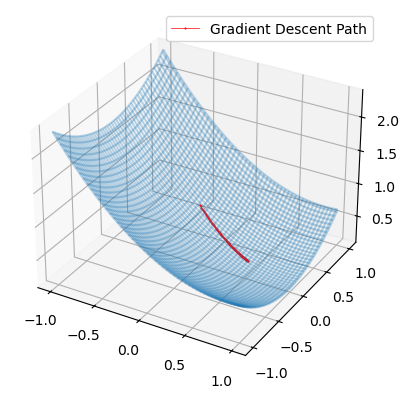

In [ ]:
# ================= 运行测试 =================
# 1. 确保使用标准化后的数据！这对于手写梯度下降非常重要
X_norm = (X - np.mean(X)) / np.std(X)
y_norm = (y - np.mean(y)) / np.std(y)

# 2. 传入合理的学习率 (alpha=0.01) 和较多的迭代次数 (ite=100)
result = fit(X_norm, y_norm, m, 0.01, 100)

result
# 1. 将 result 里的 w, b, e(即z) 分别提取成三个列表
w_history = [step[0] for step in result]
b_history = [step[1] for step in result]
z_history = [step[2] for step in result]


i = np.linspace(-1, 1, 100)
w, b = np.meshgrid(i, i)
z = np.zeros_like(w)
m = len(X_norm)

for j in range(m):
    # 注意这里使用的是缩放后的 X_norm (如果 y 也缩放了，这里用 y_norm)
    y_hat_j = w * X_norm[j] + b 
    z += (y_hat_j - y_norm[j])**2  # 如果 y 缩放了，改为 y_norm[j]

z = z / (2 * m)

fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
ax.plot_wireframe(w, b, z,alpha=0.3)

# 2. 之前画曲面的代码保持不变
# fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
# ax.plot_wireframe(w_grid, b_grid, z_grid, alpha=0.3) # 建议加上 alpha=0.3 让曲面半透明，方便看清轨迹

# ================= 核心新增：画出下降路线 =================
# 用红色的线和点，把历史轨迹画在 3D 空间中
ax.plot(w_history, b_history, z_history, 
        color='red',       # 线条颜色
        marker='o',        # 在每个坐标点画个圆圈
        markersize=0.5,      # 圆圈大小
        linewidth=0.5,       # 线条粗细
        label='Gradient Descent Path')



ax.legend()

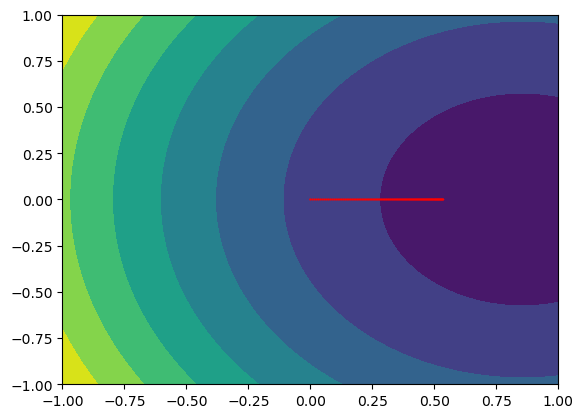

In [156]:
plt.contourf(w,b,z)
# plt.plot(w_history[0], b_history[0], marker='s', color='black', markersize=8, label='Start')
# plt.plot(w_history[-1], b_history[-1], marker='*', color='gold', markersize=12, label='End (Minimum)')
u = np.diff(w_history) 
v = np.diff(b_history)
plt.quiver(w_history[:-1], b_history[:-1], u, v, 
          angles='xy', scale_units='xy', scale=1, 
          color='red', width=0.005, headwidth=4, headlength=6, 
          label='Gradient Descent Step (dw, db)')

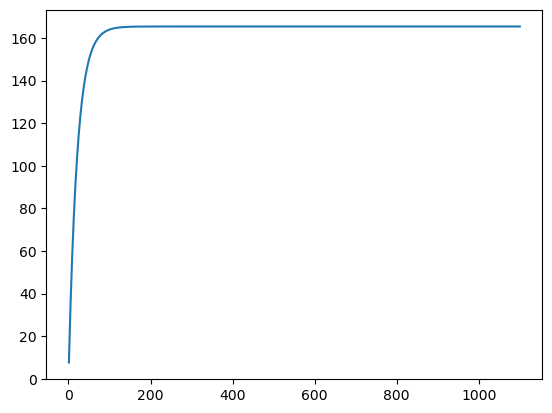

In [123]:
idx=range(1,1101)
plt.plot(idx,np.array(result)[:,0])

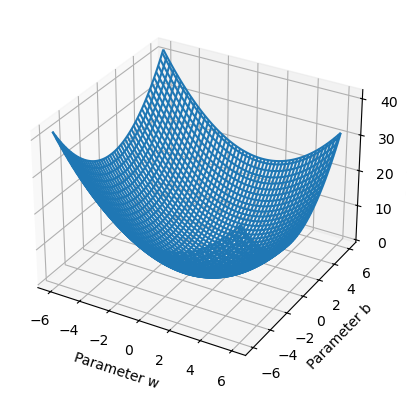

In [71]:
X_norm = (X - np.mean(X)) / np.std(X)
# 如果 y 的数值也很大（比如几十万的房价），建议对 y 也进行缩放
y_norm = (y - np.mean(y)) / np.std(y) 
# =====================================================

i = np.linspace(-6, 6, 100)
w, b = np.meshgrid(i, i)

z = np.zeros_like(w)
m = len(X_norm)

for j in range(m):
    # 注意这里使用的是缩放后的 X_norm (如果 y 也缩放了，这里用 y_norm)
    y_hat_j = w * X_norm[j] + b 
    z += (y_hat_j - y_norm[j])**2  # 如果 y 缩放了，改为 y_norm[j]

z = z / (2 * m)

fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
ax.plot_wireframe(w, b, z)

ax.set_xlabel('Parameter w')
ax.set_ylabel('Parameter b')
ax.set_zlabel('Cost J(w,b)')

plt.show()

[5.8576e+12 4.4551e+12 6.6812e+12 3.9431e+12 8.3508e+12 5.5264e+12
 4.2714e+12 3.9737e+12 3.8429e+12 4.1601e+12 5.4012e+12 5.5682e+12
 5.2621e+12 1.2464e+13 3.5312e+12 6.4030e+12 3.6759e+12 3.4422e+12
 7.2628e+12 8.4371e+12 4.9198e+12 5.2565e+12 4.4662e+12 5.4624e+12
 1.0827e+13 3.0637e+12 4.0599e+12 7.0318e+12 6.1247e+12 7.3407e+12
 5.1201e+12 2.7855e+12 5.6795e+12 8.7321e+12 5.0422e+12 4.0015e+12
 3.4505e+12 5.9355e+12 1.1732e+13 6.0190e+12 4.6332e+12 6.2304e+12
 7.1459e+12 3.3420e+12 2.3736e+12 5.1563e+12 3.3504e+12]
[-3.9745e+20 -3.0229e+20 -4.5334e+20 -2.6755e+20 -5.6663e+20 -3.7499e+20
 -2.8983e+20 -2.6963e+20 -2.6075e+20 -2.8228e+20 -3.6649e+20 -3.7782e+20
 -3.5705e+20 -8.4570e+20 -2.3961e+20 -4.3446e+20 -2.4942e+20 -2.3356e+20
 -4.9281e+20 -5.7249e+20 -3.3382e+20 -3.5667e+20 -3.0305e+20 -3.7064e+20
 -7.3468e+20 -2.0788e+20 -2.7548e+20 -4.7713e+20 -4.1558e+20 -4.9809e+20
 -3.4742e+20 -1.8900e+20 -3.8537e+20 -5.9250e+20 -3.4213e+20 -2.7152e+20
 -2.3413e+20 -4.0274e+20 -7.9604e+20

(0.0, 699900.0)

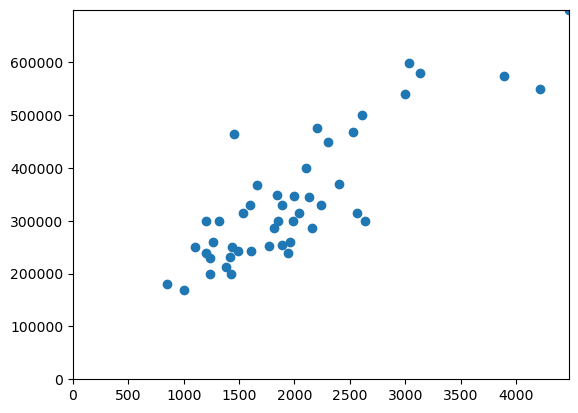

In [48]:

fig,ax=plt.subplots()
ax.scatter(X,y,)
for _ in result:
    y_hat=_[0]*X+_[1]
    ax.plot(X,y_hat)
    print(y_hat)
ax.set_xlim(0,X.max())
ax.set_ylim(0,y.max())
